In [12]:

# Exploratory Data Analysis + Feature Engineering

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [14]:
# Load the Dataset

books = pd.read_csv(r"C:\Users\saumitra sundar rath\Books.csv",encoding='latin-1')
ratings = pd.read_csv(r"C:\Users\saumitra sundar rath\Ratings.csv",encoding='latin-1')
users = pd.read_csv(r"C:\Users\saumitra sundar rath\Users.csv",encoding='latin-1')

print("Datasets Loaded Successfully!")

C:\Users\saumitra sundar rath\AppData\Local\Temp\ipykernel_8080\2810942799.py:3: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(r"C:\Users\saumitra sundar rath\Books.csv",encoding='latin-1')


Datasets Loaded Successfully!


In [16]:
users.info()
books.info()
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 6.4 MB
<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  str   
 1   Book-Title           271360 non-null  str   
 2   Book-Author          271358 non-null  str   
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  str   
 5   Image-URL-S          271360 non-null  str   
 6   Image-URL-M          271360 non-null  str   
 7   Image-URL-L          271357 non-null  str   
dtypes: object(1), str(7)
memory usage: 16.6

In [17]:
# Dataset Overview

print("\n--- Books Dataset ---")
print("Shape:", books.shape)
print(books.head())

print("\n--- Ratings Dataset ---")
print("Shape:", ratings.shape)
print(ratings.head())

print("\n--- Users Dataset ---")
print("Shape:", users.shape)
print(users.head())



--- Books Dataset ---
Shape: (271360, 8)
         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                2002     Oxford University Press   
1  Richard Bruce Wright                2001       HarperFlamingo Canada   
2          Carlo D'Este                1991             HarperPerennial   
3      Gina Bari Kolata                1999        Farrar Straus Giroux   
4       E. J. W. Barber                1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/01951

In [10]:
# Checking Missing Values

print("\nMissing Values in Books Dataset:")
print(books.isnull().sum())

print("\nMissing Values in Users Dataset:")
print(users.isnull().sum())

print("\nMissing Values in Ratings Dataset:")
print(ratings.isnull().sum())




Missing Values in Books Dataset:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Missing Values in Users Dataset:
User-ID          0
Location         0
Age         110762
dtype: int64

Missing Values in Ratings Dataset:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


In [18]:
# Data Cleaning

# Ratings contain:
# Explicit Ratings: 1–10
# Implicit Ratings: 0

print("\nRatings Distribution Before Cleaning:")
print(ratings["Book-Rating"].value_counts().head(15))

# Remove implicit ratings (rating = 0)
ratings_clean = ratings[ratings["Book-Rating"] > 0]

print("\nRatings Shape After Removing Implicit Ratings:")
print(ratings_clean.shape)



Ratings Distribution Before Cleaning:
Book-Rating
0     716109
8     103736
10     78610
7      76457
9      67541
5      50974
6      36924
4       8904
3       5996
2       2759
1       1770
Name: count, dtype: int64

Ratings Shape After Removing Implicit Ratings:
(433671, 3)


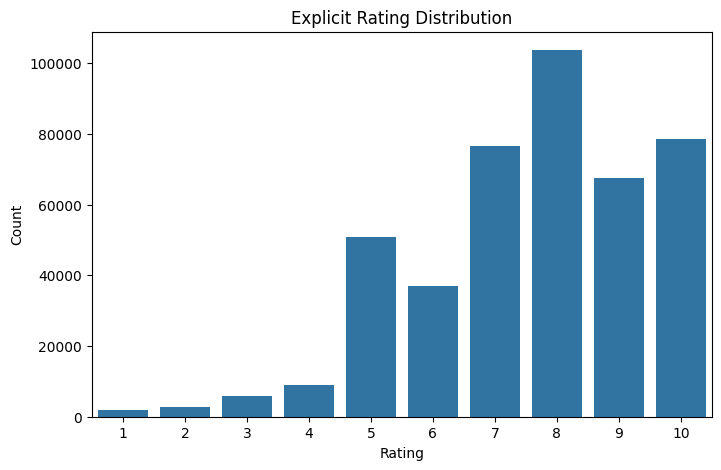

In [19]:
#Explicit Ratings Only (1–10)
ratings_clean = ratings[ratings['Book-Rating'] > 0]

plt.figure(figsize=(8,5))
sns.countplot(x='Book-Rating', data=ratings_clean)
plt.title("Explicit Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [20]:
# Merge Ratings + Books Data

# Merging to get book details along with ratings
data = ratings_clean.merge(books, on="ISBN")

print("\nMerged Dataset Shape (Ratings + Books):", data.shape)
print(data.head())



Merged Dataset Shape (Ratings + Books): (383842, 10)
   User-ID        ISBN  Book-Rating  \
0   276726  0155061224            5   
1   276729  052165615X            3   
2   276729  0521795028            6   
3   276744  038550120X            7   
4   276747  0060517794            9   

                                          Book-Title    Book-Author  \
0                                   Rites of Passage     Judith Rae   
1                                     Help!: Level 1  Philip Prowse   
2  The Amsterdam Connection : Level 4 (Cambridge ...    Sue Leather   
3                                    A Painted House   JOHN GRISHAM   
4                           Little Altars Everywhere  Rebecca Wells   

  Year-Of-Publication                   Publisher  \
0                2001                      Heinle   
1                1999  Cambridge University Press   
2                2001  Cambridge University Press   
3                2001                   Doubleday   
4                20

In [21]:
# Exploratory Data Analysis (EDA)

# Unique Counts
print("\nTotal Unique Users:", data["User-ID"].nunique())
print("Total Unique Books:", data["ISBN"].nunique())

# Ratings Summary
print("\nRatings Summary Statistics:")
print(data["Book-Rating"].describe())




Total Unique Users: 68091
Total Unique Books: 149836

Ratings Summary Statistics:
count    383842.000000
mean          7.626701
std           1.841339
min           1.000000
25%           7.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: Book-Rating, dtype: float64


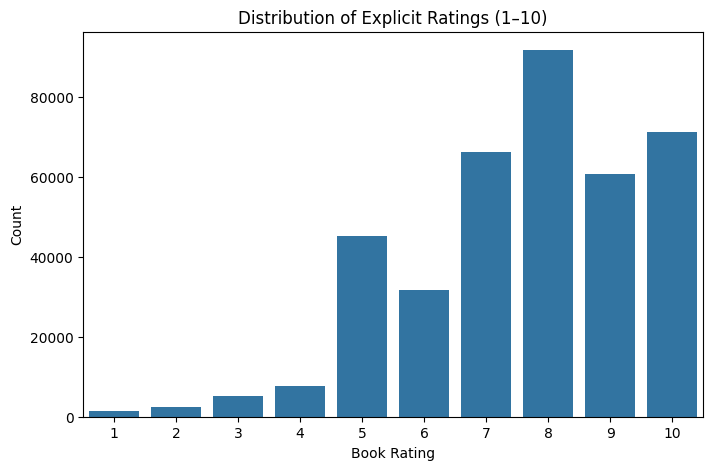

In [22]:
# Ratings Distribution Plot

plt.figure(figsize=(8,5))
sns.countplot(x="Book-Rating", data=data)
plt.title("Distribution of Explicit Ratings (1–10)")
plt.xlabel("Book Rating")
plt.ylabel("Count")
plt.show()



Top 10 Most Rated Books:
Book-Title
The Lovely Bones: A Novel                           707
Wild Animus                                         581
The Da Vinci Code                                   494
The Secret Life of Bees                             406
The Nanny Diaries: A Novel                          393
The Red Tent (Bestselling Backlist)                 383
Bridget Jones's Diary                               377
A Painted House                                     366
Life of Pi                                          336
Harry Potter and the Chamber of Secrets (Book 2)    326
Name: count, dtype: int64


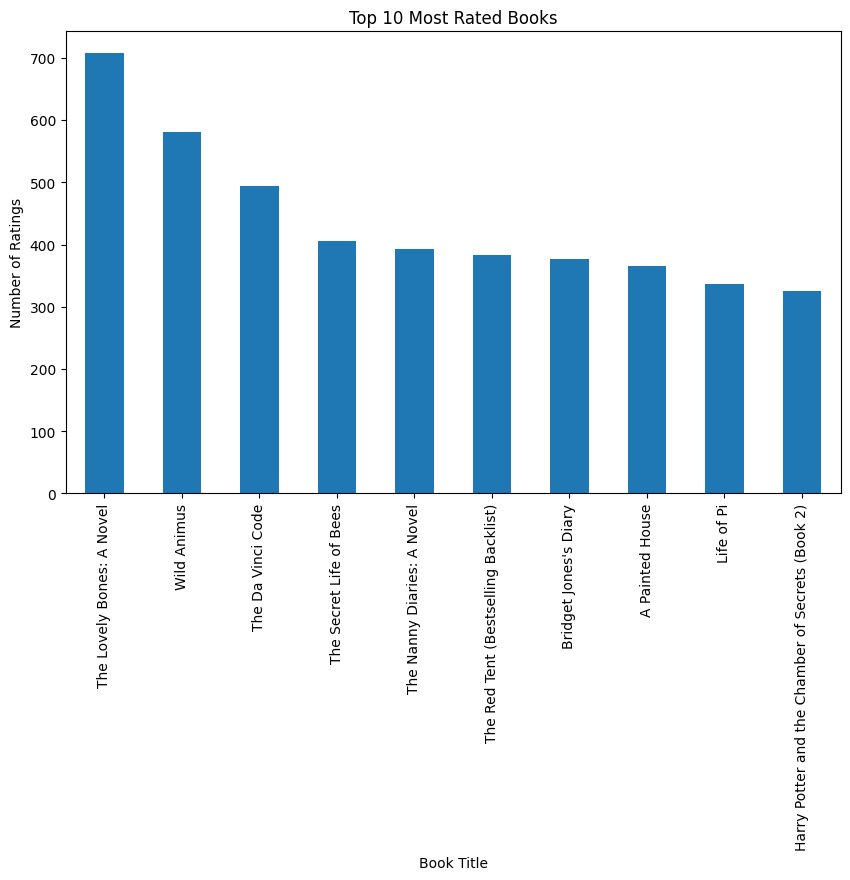

In [23]:
# Step 9: Most Rated Books

top_rated_books = data["Book-Title"].value_counts().head(10)

print("\nTop 10 Most Rated Books:")
print(top_rated_books)

plt.figure(figsize=(10,6))
top_rated_books.plot(kind="bar")
plt.title("Top 10 Most Rated Books")
plt.xlabel("Book Title")
plt.ylabel("Number of Ratings")
plt.show()


User Rating Count Summary:
count    68091.000000
mean         5.637191
std         41.742511
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       6943.000000
Name: Book-Rating, dtype: float64


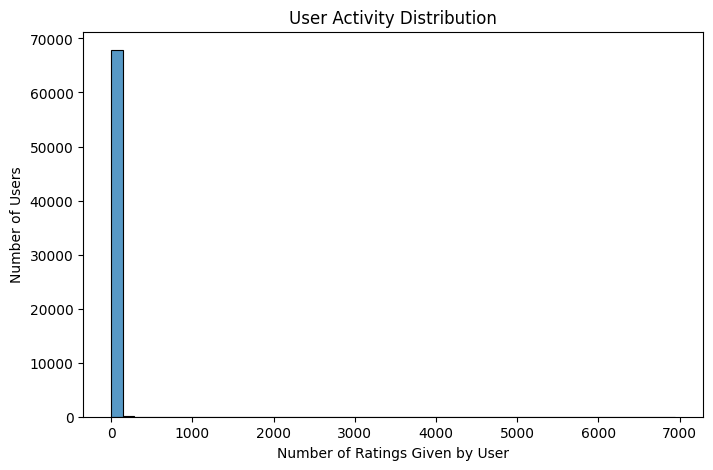

In [24]:
# User Activity Analysis

user_rating_counts = data.groupby("User-ID")["Book-Rating"].count()

print("\nUser Rating Count Summary:")
print(user_rating_counts.describe())

plt.figure(figsize=(8,5))
sns.histplot(user_rating_counts, bins=50)
plt.title("User Activity Distribution")
plt.xlabel("Number of Ratings Given by User")
plt.ylabel("Number of Users")
plt.show()


In [25]:
# Feature Engineering

# Feature Engineering means generating meaningful features such as:
# - Average rating of each book
# - Total number of ratings per book
# - Popularity score


# Book-Level Features


book_features = data.groupby("ISBN").agg(
    avg_rating=("Book-Rating", "mean"),
    rating_count=("Book-Rating", "count")
).reset_index()

print("\nBook Feature Dataset:")
print(book_features.head())




Book Feature Dataset:
         ISBN  avg_rating  rating_count
0  0000913154         8.0             1
1  0001046438         9.0             1
2  000104687X         6.0             1
3  0001047213         9.0             1
4  0001047973         9.0             2


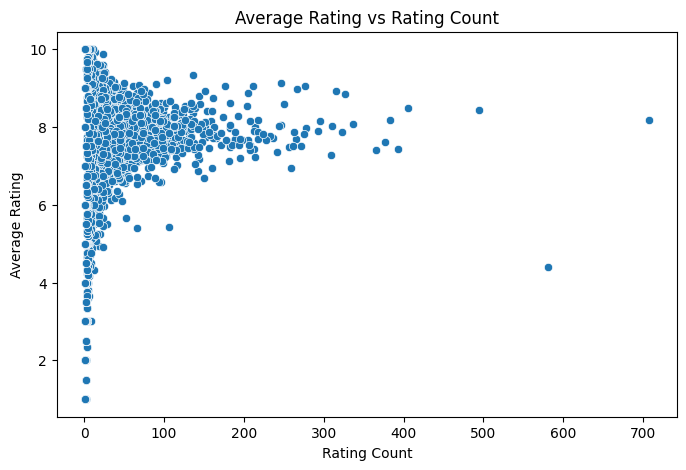

In [26]:
#Average Rating vs Rating Count
book_stats = ratings_clean.merge(books, on="ISBN").groupby("Book-Title").agg(
    avg_rating=('Book-Rating', 'mean'),
    rating_count=('Book-Rating', 'count')
)

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='rating_count',
    y='avg_rating',
    data=book_stats
)
plt.title("Average Rating vs Rating Count")
plt.xlabel("Rating Count")
plt.ylabel("Average Rating")
plt.show()


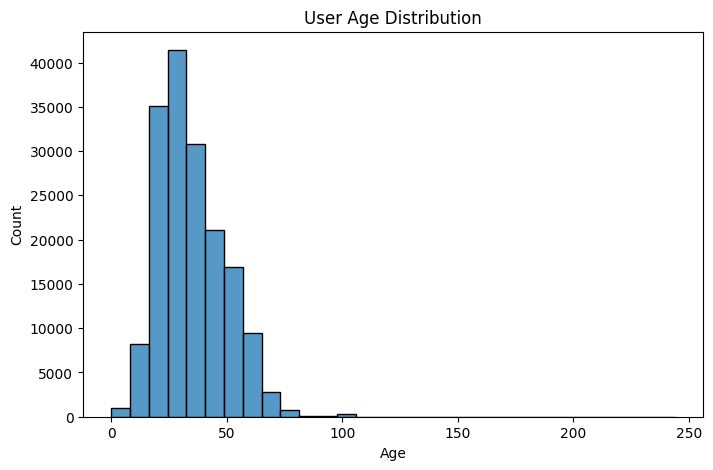

In [27]:
#User Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(users['Age'].dropna(), bins=30)
plt.title("User Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [28]:
# Merge Book Features with Book Info

book_features = book_features.merge(
    books[["ISBN", "Book-Title", "Book-Author", "Year-Of-Publication"]],
    on="ISBN"
)

print("\nBook Features with Details:")
print(book_features.head())




Book Features with Details:
         ISBN  avg_rating  rating_count  \
0  0000913154         8.0             1   
1  0001046438         9.0             1   
2  000104687X         6.0             1   
3  0001047213         9.0             1   
4  0001047973         9.0             2   

                                          Book-Title  \
0  The Way Things Work: An Illustrated Encycloped...   
1                                               Liar   
2  T.S. Eliot Reading \The Wasteland\" and Other ...   
3                                   The Fighting Man   
4                                    Brave New World   

                     Book-Author Year-Of-Publication  
0  C. van Amerongen (translator)                1967  
1                    Stephen Fry                   0  
2                     T.S. Eliot                1993  
3                 Gerald Seymour                1993  
4                  Aldous Huxley                1999  


In [29]:
# Popularity Score Feature

# Popularity = Average Rating × Rating Count
book_features["popularity_score"] = (
    book_features["avg_rating"] * book_features["rating_count"]
)

print("\nBook Features After Adding Popularity Score:")
print(book_features.head())



Book Features After Adding Popularity Score:
         ISBN  avg_rating  rating_count  \
0  0000913154         8.0             1   
1  0001046438         9.0             1   
2  000104687X         6.0             1   
3  0001047213         9.0             1   
4  0001047973         9.0             2   

                                          Book-Title  \
0  The Way Things Work: An Illustrated Encycloped...   
1                                               Liar   
2  T.S. Eliot Reading \The Wasteland\" and Other ...   
3                                   The Fighting Man   
4                                    Brave New World   

                     Book-Author Year-Of-Publication  popularity_score  
0  C. van Amerongen (translator)                1967               8.0  
1                    Stephen Fry                   0               9.0  
2                     T.S. Eliot                1993               6.0  
3                 Gerald Seymour                1993              

In [30]:
#Top Recommended Popular Books

top_popular_books = book_features.sort_values(
    by="popularity_score",
    ascending=False
).head(10)

print("\nTop 10 Popular Books Based on Feature Engineering:")
print(top_popular_books[["Book-Title", "avg_rating", "rating_count", "popularity_score"]])



Top 10 Popular Books Based on Feature Engineering:
                                               Book-Title  avg_rating  \
21945                           The Lovely Bones: A Novel    8.185290   
38819                                   The Da Vinci Code    8.435318   
18058                 The Red Tent (Bestselling Backlist)    8.182768   
68898   Harry Potter and the Sorcerer's Stone (Harry P...    8.939297   
12325                             The Secret Life of Bees    8.452769   
117745                                        Wild Animus    4.390706   
4131      Divine Secrets of the Ya-Ya Sisterhood: A Novel    7.887500   
51799   Where the Heart Is (Oprah's Book Club (Paperba...    8.142373   
57625                           Girl with a Pearl Earring    7.982014   
73422                                 Angels &amp; Demons    8.100372   

        rating_count  popularity_score  
21945            707            5787.0  
38819            487            4108.0  
18058            383 

In [31]:
# Save Feature Engineered Data

book_features.to_csv("Book_Features_Phase1.csv", index=False)

print("\nFeature Engineered Dataset Saved as Book_Features_Phase1.csv")




Feature Engineered Dataset Saved as Book_Features_Phase1.csv
